<a href="https://colab.research.google.com/github/sanikatakarkhede/ML_models-TAE-1/blob/main/Email_Spam_Detection(70_30).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TOPIC :- Email Spam Detection

ML TAE 1

Group No.3: Riya Nitnaware_CS23015 , Sanika Takarkhede_CS23016

In [36]:
# STEP 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

from scipy.sparse import hstack

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [37]:
# STEP 2: Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
path = "/content/drive/MyDrive/ML_dataset/spam.csv"
df = pd.read_csv(path, encoding='latin-1')
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [39]:
print(df.shape)

(5572, 5)


In [40]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None


In [41]:
df = df.iloc[:, :2]
df.columns = ['label', 'message']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [42]:
# TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['message'])
y = df['label']


In [44]:

print(df.head())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [45]:
# CONFUSION MATRIX FUNCTION
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5,4))

    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.colorbar()

    plt.xticks([0,1], ['Ham','Spam'])
    plt.yticks([0,1], ['Ham','Spam'])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j],
                     ha='center',
                     va='center',
                     color='black',
                     fontsize=13)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [46]:
# 70:30 SPLIT
print("\n========= 70:30 SPLIT =========")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

results_70 = {}


========= 70:30 SPLIT =========



--- Logistic Regression ---
Accuracy: 0.9575358851674641
Confusion Matrix:
 [[1453    0]
 [  71  148]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      1453
           1       1.00      0.68      0.81       219

    accuracy                           0.96      1672
   macro avg       0.98      0.84      0.89      1672
weighted avg       0.96      0.96      0.95      1672



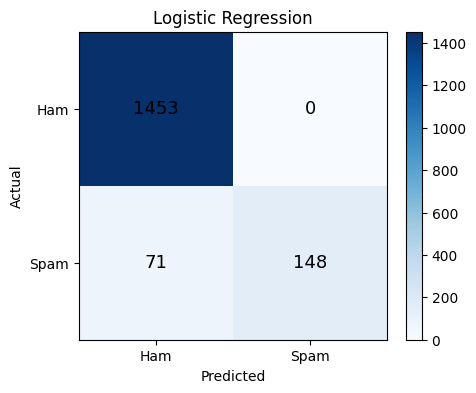

In [47]:
print("\n--- Logistic Regression ---")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

cm = confusion_matrix(y_test, pred_lr)

print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Confusion Matrix:\n", cm)
print(classification_report(y_test, pred_lr))

plot_confusion_matrix(cm, "Logistic Regression")

results_70["Logistic Regression"] = accuracy_score(y_test, pred_lr)


--- Decision Tree ---
Accuracy: 0.9665071770334929
Confusion Matrix:
 [[1427   26]
 [  30  189]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1453
           1       0.88      0.86      0.87       219

    accuracy                           0.97      1672
   macro avg       0.93      0.92      0.93      1672
weighted avg       0.97      0.97      0.97      1672



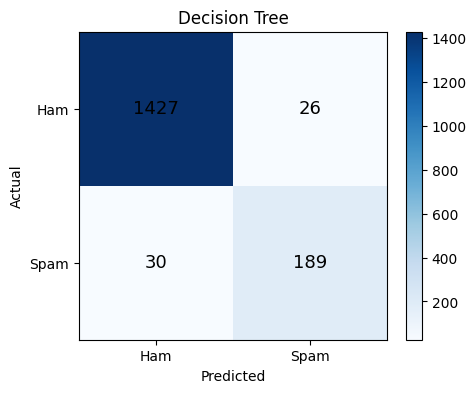

In [48]:
print("\n--- Decision Tree ---")

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

cm = confusion_matrix(y_test, pred_dt)

print("Accuracy:", accuracy_score(y_test, pred_dt))
print("Confusion Matrix:\n", cm)
print(classification_report(y_test, pred_dt))

plot_confusion_matrix(cm, "Decision Tree")

results_70["Decision Tree"] = accuracy_score(y_test, pred_dt)


--- Naive Bayes ---
Accuracy: 0.9569377990430622
Confusion Matrix:
 [[1453    0]
 [  72  147]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      1453
           1       1.00      0.67      0.80       219

    accuracy                           0.96      1672
   macro avg       0.98      0.84      0.89      1672
weighted avg       0.96      0.96      0.95      1672



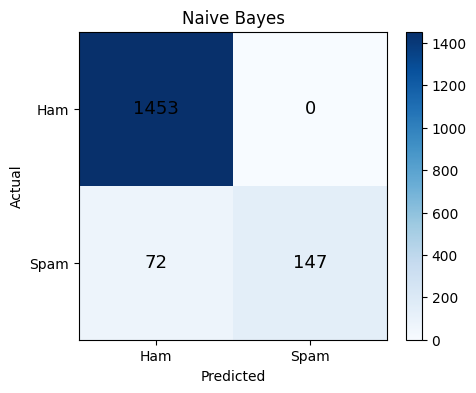

In [49]:
print("\n--- Naive Bayes ---")

nb = MultinomialNB()
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

cm = confusion_matrix(y_test, pred_nb)

print("Accuracy:", accuracy_score(y_test, pred_nb))
print("Confusion Matrix:\n", cm)
print(classification_report(y_test, pred_nb))

plot_confusion_matrix(cm, "Naive Bayes")

results_70["Naive Bayes"] = accuracy_score(y_test, pred_nb)


--- SVM ---
Accuracy: 0.9754784688995215
Confusion Matrix:
 [[1453    0]
 [  41  178]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1453
           1       1.00      0.81      0.90       219

    accuracy                           0.98      1672
   macro avg       0.99      0.91      0.94      1672
weighted avg       0.98      0.98      0.97      1672



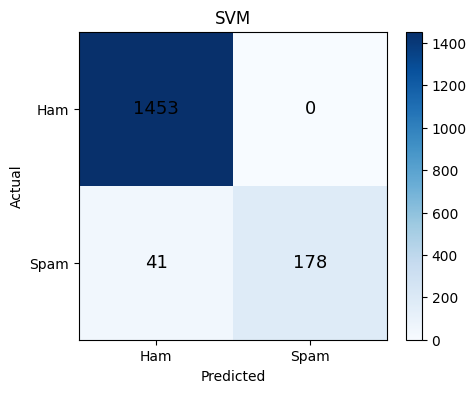

In [50]:
print("\n--- SVM ---")

svm = SVC()
svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

cm = confusion_matrix(y_test, pred_svm)

print("Accuracy:", accuracy_score(y_test, pred_svm))
print("Confusion Matrix:\n", cm)
print(classification_report(y_test, pred_svm))

plot_confusion_matrix(cm, "SVM")

results_70["SVM"] = accuracy_score(y_test, pred_svm)


--- Random Forest ---
Accuracy: 0.9784688995215312
Confusion Matrix:
 [[1453    0]
 [  36  183]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1453
           1       1.00      0.84      0.91       219

    accuracy                           0.98      1672
   macro avg       0.99      0.92      0.95      1672
weighted avg       0.98      0.98      0.98      1672



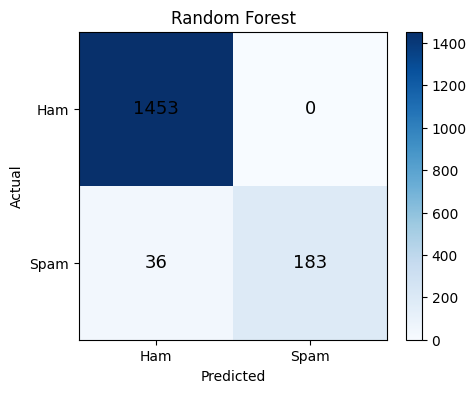

In [51]:
print("\n--- Random Forest ---")

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, pred_rf)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Confusion Matrix:\n", cm)
print(classification_report(y_test, pred_rf))

plot_confusion_matrix(cm, "Random Forest")

results_70["Random Forest"] = accuracy_score(y_test, pred_rf)


--- KNN ---
Accuracy: 0.9102870813397129
Confusion Matrix:
 [[1453    0]
 [ 150   69]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1453
           1       1.00      0.32      0.48       219

    accuracy                           0.91      1672
   macro avg       0.95      0.66      0.72      1672
weighted avg       0.92      0.91      0.89      1672



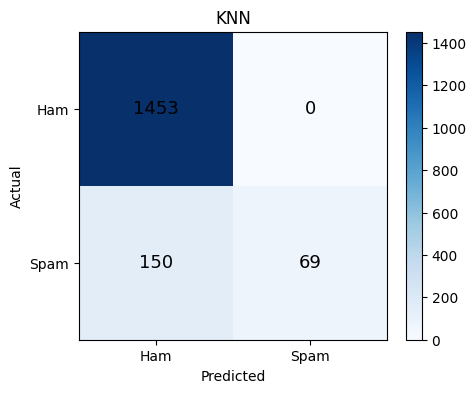

In [52]:
print("\n--- KNN ---")

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

cm = confusion_matrix(y_test, pred_knn)

print("Accuracy:", accuracy_score(y_test, pred_knn))
print("Confusion Matrix:\n", cm)
print(classification_report(y_test, pred_knn))

plot_confusion_matrix(cm, "KNN")

results_70["KNN"] = accuracy_score(y_test, pred_knn)

In [53]:
print("\n===== MODEL COMPARISON TABLE (70:30) =====")

table_data = []

model_dict = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Naive Bayes": nb,
    "SVM": svm,
    "Random Forest": rf,
    "KNN": knn
}

for name, model in model_dict.items():

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    table_data.append([name, acc, prec, rec, f1])

df_table = pd.DataFrame(
    table_data,
    columns=["Model","Accuracy","Precision","Recall","F1-Score"]
)

df_table["Accuracy"] = df_table["Accuracy"] * 100

print(df_table)


===== MODEL COMPARISON TABLE (70:30) =====
                 Model   Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  95.753589    1.00000  0.675799  0.806540
1        Decision Tree  96.650718    0.87907  0.863014  0.870968
2          Naive Bayes  95.693780    1.00000  0.671233  0.803279
3                  SVM  97.547847    1.00000  0.812785  0.896725
4        Random Forest  97.846890    1.00000  0.835616  0.910448
5                  KNN  91.028708    1.00000  0.315068  0.479167


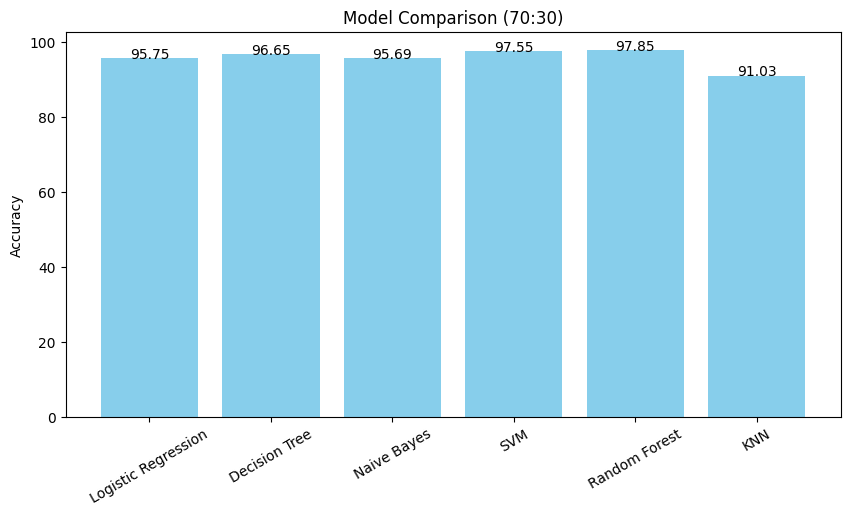

In [54]:
# COMPARISON GRAPH
plt.figure(figsize=(10,5))
bars = plt.bar(df_table["Model"], df_table["Accuracy"], color='skyblue')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             height,
             f"{height:.2f}",
             ha='center')
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Comparison (70:30)")
plt.show()


In [55]:
# BEST MODEL
best_model_name = df_table.loc[df_table["Accuracy"].idxmax(),"Model"]

print("\nBest Model:",best_model_name)


Best Model: Random Forest


In [58]:
print("\n====== SPAM DETECTION ======")

final_model = model_dict[best_model_name]

import numpy as np
spam_index = np.where(y_test.values == 1)[0][:3]
ham_index = np.where(y_test.values == 0)[0][:3]

sample_index = np.concatenate([spam_index, ham_index])

X_sample = X_test[sample_index]
y_actual = y_test.iloc[sample_index]

pred = final_model.predict(X_sample)

for i in range(len(pred)):

    print("\n----------------------------")
    print("Message:", df.iloc[sample_index[i]]['message'])

    print("Actual:",
          "SPAM" if y_actual.iloc[i]==1 else "NOT SPAM")

    print("Predicted:",
          "SPAM" if pred[i]==1 else "NOT SPAM")


====== SPAM DETECTION ======

----------------------------
Message: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Actual: SPAM
Predicted: SPAM

----------------------------
Message: Nah I don't think he goes to usf, he lives around here though
Actual: SPAM
Predicted: SPAM

----------------------------
Message: SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info
Actual: SPAM
Predicted: SPAM

----------------------------
Message: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Actual: NOT SPAM
Predicted: NOT SPAM

----------------------------
Message: Ok lar... Joking wif u oni...
Actual: NOT SPAM
Predicted: NOT SPAM

----------------------------
Message: U dun say so early hor... U c already then say...
Actual: NOT SPAM
Predicted: 